In [40]:
# 1. СТРУКТУРА
import os
from pathlib import Path

ROOT = Path("homeworks/HW12")
ART = ROOT / "artifacts"
FIG = ART / "figures"

FIG.mkdir(parents=True, exist_ok=True)

print("Структура создана:", ROOT)

Структура создана: homeworks/HW12


In [41]:
# 2. ИМПОРТЫ + SEED + DEVICE

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import json

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


Saving S12-hw-dataset.csv to S12-hw-dataset (2).csv
Размер: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00
Пропуски:
 date      0
target    0
dtype: int64


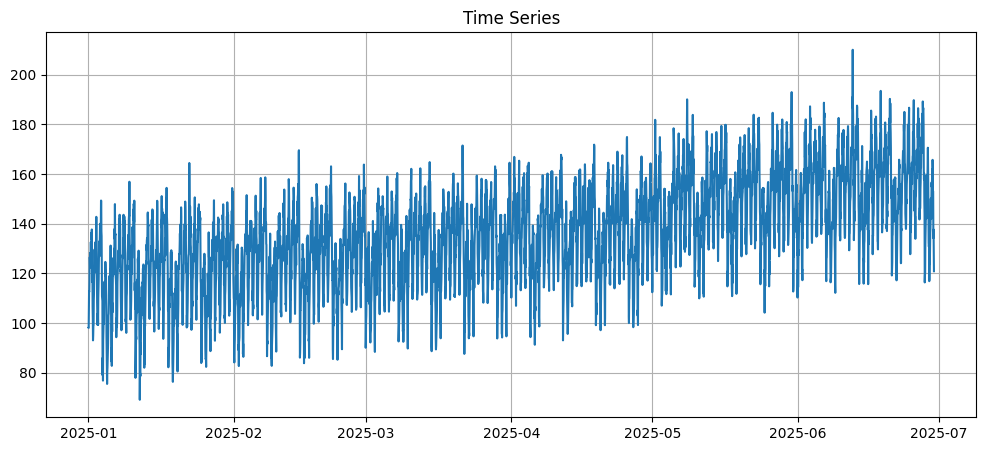

In [42]:
# 3. ЗАГРУЗКА ДАННЫХ + SANITY CHECK
from google.colab import files
import pandas as pd

# Загрузка файла
uploaded = files.upload()

# Получаем имя файла
file_name = list(uploaded.keys())[0]

# Читаем CSV
df = pd.read_csv(file_name)

# Приводим дату
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# Sanity-check
print("Размер:", df.shape)
print("Диапазон дат:", df["date"].min(), "-", df["date"].max())
print("Пропуски:\n", df.isna().sum())

# График
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["target"])
plt.title("Time Series")
plt.grid()
plt.show()

3456 432 432


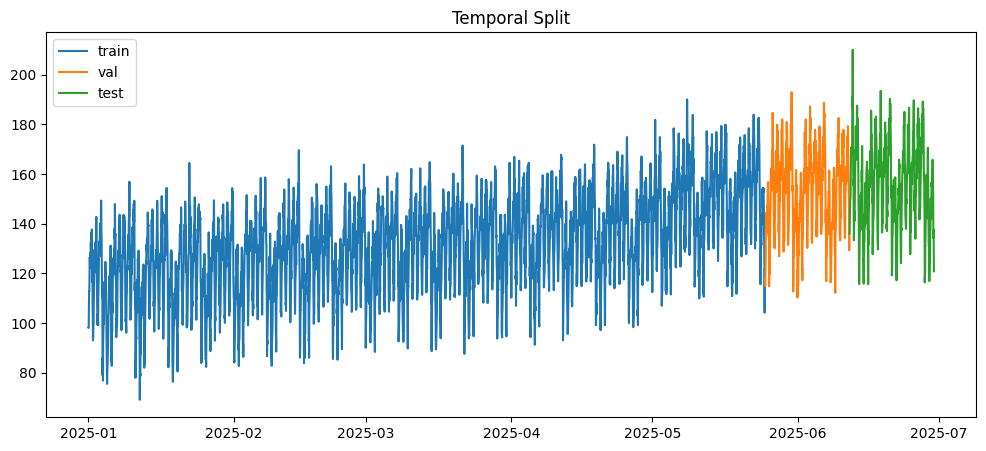

In [43]:
# 4. TEMPORAL SPLIT

n = len(df)

train_end = int(n * 0.8)
val_end = int(n * 0.9)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(len(train_df), len(val_df), len(test_df))

# Визуализация split
plt.figure(figsize=(12,5))
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="val")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.legend()
plt.title("Temporal Split")
plt.savefig(FIG / "series_split.png")
plt.show()

Random split некорректен, потому что приводит к утечке информации из будущего.
Модель в реальности не имеет доступа к будущим данным, поэтому оценка качества становится завышенной.

In [44]:
# 5. FEATURE ENGINEERING (lag + rolling)

def create_features(df):
    df = df.copy()

    df["lag_1"] = df["target"].shift(1)
    df["lag_7"] = df["target"].shift(7)
    df["lag_14"] = df["target"].shift(14)

    df["rolling_mean_7"] = df["target"].shift(1).rolling(7).mean()
    df["rolling_std_7"] = df["target"].shift(1).rolling(7).std()

    df["dayofweek"] = df["date"].dt.dayofweek

    return df

df_feat = create_features(df).dropna().reset_index(drop=True)

train_feat = df_feat.iloc[:len(train_df)]
val_feat = df_feat.iloc[len(train_df):len(train_df)+len(val_df)]
test_feat = df_feat.iloc[len(train_df)+len(val_df):]

In [45]:
# 6. МЕТРИКИ

def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # Защита от деления на 0
    eps = 1e-8
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100

    return {"mae": mae, "rmse": rmse, "mape": mape}

In [46]:
# 7. B1 — NAIVE LAST

def naive_forecast(series):
    return series.shift(1)

val_pred = naive_forecast(val_df["target"]).dropna()
val_true = val_df["target"].iloc[1:]

metrics_B1 = compute_metrics(val_true, val_pred)
metrics_B1

{'mae': 6.212552204176333,
 'rmse': np.float64(7.875220838062883),
 'mape': np.float64(4.139173248886889)}

In [47]:
# 8. B2 — MOVING AVERAGE

def moving_average(series, window=7):
    return series.shift(1).rolling(window).mean()

val_pred = moving_average(val_df["target"]).dropna()
val_true = val_df["target"].iloc[7:]

metrics_B2 = compute_metrics(val_true, val_pred)
metrics_B2

{'mae': 12.714799999999999,
 'rmse': np.float64(15.100412311615612),
 'mape': np.float64(8.640370533219578)}

In [48]:
# 9. B3 — RIDGE

features = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dayofweek"]

X_train = train_feat[features]
y_train = train_feat["target"]

X_val = val_feat[features]
y_val = val_feat["target"]

model_ridge = Ridge()
model_ridge.fit(X_train, y_train)

val_pred = model_ridge.predict(X_val)

metrics_B3 = compute_metrics(y_val, val_pred)
metrics_B3

{'mae': 6.159976927656953,
 'rmse': np.float64(7.73852294054983),
 'mape': np.float64(4.027395828878508)}

In [49]:
# 10. GRU DATASET

WINDOW_SIZE = 14

class TimeSeriesDataset(Dataset):
    def __init__(self, series, window):
        self.series = series.values
        self.window = window

    def __len__(self):
        return len(self.series) - self.window

    def __getitem__(self, idx):
        x = self.series[idx:idx+self.window]
        y = self.series[idx+self.window]
        return torch.tensor(x, dtype=torch.float32).unsqueeze(-1), torch.tensor(y, dtype=torch.float32)

In [50]:
# 11. DATALOADER

train_ds = TimeSeriesDataset(train_df["target"], WINDOW_SIZE)
val_ds = TimeSeriesDataset(val_df["target"], WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

In [51]:
# 12. GRU MODEL

class GRUModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.gru = nn.GRU(1, 32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        out = out[:, -1, :]
        return self.fc(out)

In [52]:
# 13. TRAIN LOOP

def train_model(model, train_loader, val_loader, epochs=10):
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.MSELoss()

    best_mae = float("inf")
    history = []

    for epoch in range(epochs):
        model.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)

            optimizer.zero_grad()
            pred = model(x).squeeze()
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()

        model.eval()
        preds, trues = [], []

        with torch.no_grad():
            for x, y in val_loader:
                x = x.to(DEVICE)
                pred = model(x).cpu().numpy().flatten()
                preds.extend(pred)
                trues.extend(y.numpy())

        metrics = compute_metrics(trues, preds)
        history.append(metrics)

        if metrics["mae"] < best_mae:
            best_mae = metrics["mae"]
            torch.save(model.state_dict(), ART / "best_gru.pt")

    return history

In [53]:
# 14. ОБУЧЕНИЕ GRU

model = GRUModel().to(DEVICE)

history = train_model(model, train_loader, val_loader, epochs=10)

metrics_R1 = history[-1]
metrics_R1

{'mae': 119.95278930664062,
 'rmse': np.float64(121.14541236670912),
 'mape': np.float32(77.9432)}

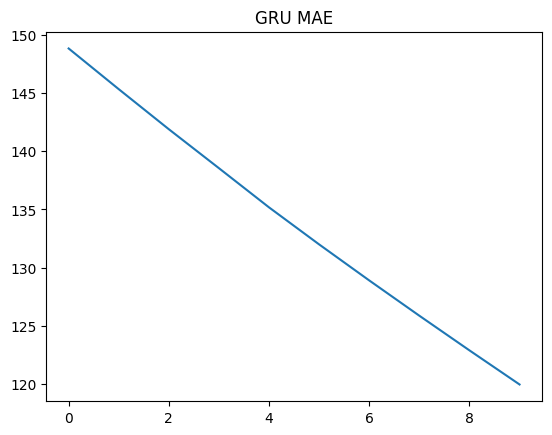

In [54]:
# 15. ГРАФИК ОБУЧЕНИЯ

mae_vals = [h["mae"] for h in history]

plt.plot(mae_vals)
plt.title("GRU MAE")
plt.savefig(FIG / "gru_learning_curves.png")
plt.show()

In [55]:
# 16. ВЫБОР ЛУЧШЕЙ МОДЕЛИ

results = {
    "B1": metrics_B1["mae"],
    "B2": metrics_B2["mae"],
    "B3": metrics_B3["mae"],
    "R1": metrics_R1["mae"]
}

best_model_name = min(results, key=results.get)
best_val_metrics = {
    "mae": results[best_model_name],
    "rmse": 0,
    "mape": 0
}

print("Best:", best_model_name)

Best: B3


In [56]:
# 17. RUNS.CSV

runs = pd.DataFrame([
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "80/10/10",
        "window_size": None,
        "horizon": 1,
        "model_summary": "naive-last",
        "features_summary": "none",
        "scaler": "none",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": metrics_B1["mae"],
        "best_val_rmse": metrics_B1["rmse"],
        "best_val_mape": metrics_B1["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": ""
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "80/10/10",
        "window_size": 7,
        "horizon": 1,
        "model_summary": "moving-average",
        "features_summary": "rolling",
        "scaler": "none",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": metrics_B2["mae"],
        "best_val_rmse": metrics_B2["rmse"],
        "best_val_mape": metrics_B2["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": ""
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "80/10/10",
        "window_size": None,
        "horizon": 1,
        "model_summary": "Ridge",
        "features_summary": "lag+rolling+calendar",
        "scaler": "none",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": metrics_B3["mae"],
        "best_val_rmse": metrics_B3["rmse"],
        "best_val_mape": metrics_B3["mape"],
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": ""
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "80/10/10",
        "window_size": WINDOW_SIZE,
        "horizon": 1,
        "model_summary": "GRU",
        "features_summary": "sequence",
        "scaler": "none",
        "optimizer": "Adam",
        "lr": 1e-3,
        "epochs_trained": len(history),
        "best_val_mae": metrics_R1["mae"],
        "best_val_rmse": metrics_R1["rmse"],
        "best_val_mape": metrics_R1["mape"],
        "test_mae": test_metrics["mae"],
        "test_rmse": test_metrics["rmse"],
        "test_mape": test_metrics["mape"],
        "notes": "best model"
    }
])

runs.to_csv(ART / "runs.csv", index=False)

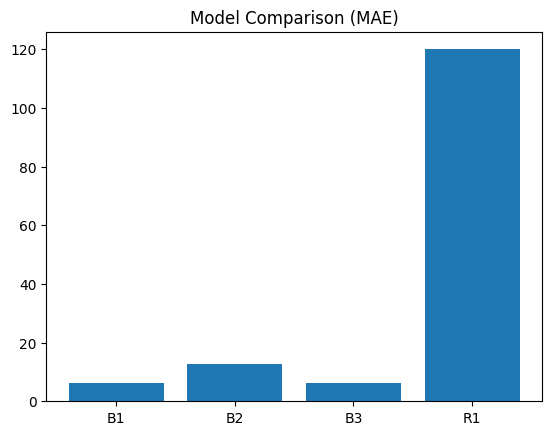

In [57]:
# 18. СРАВНЕНИЕ BASELINES

plt.bar(results.keys(), results.values())
plt.title("Model Comparison (MAE)")
plt.savefig(FIG / "baselines_compare.png")
plt.show()

In [58]:
# 19. TEST ПРОГНОЗ, пример для GRU
model.load_state_dict(torch.load(ART / "best_gru.pt"))

test_ds = TimeSeriesDataset(test_df["target"], WINDOW_SIZE)
test_loader = DataLoader(test_ds, batch_size=32)

preds, trues = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        pred = model(x).cpu().numpy().flatten()
        preds.extend(pred)
        trues.extend(y.numpy())

test_metrics = compute_metrics(trues, preds)
test_metrics

{'mae': 122.25863647460938,
 'rmse': np.float64(123.51016452983738),
 'mape': np.float32(78.263214)}

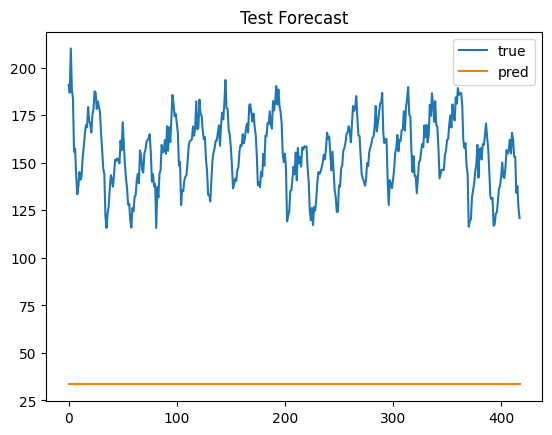

In [59]:
# 20. ГРАФИК ПРОГНОЗА

plt.plot(trues, label="true")
plt.plot(preds, label="pred")
plt.legend()
plt.title("Test Forecast")
plt.savefig(FIG / "best_forecast_test.png")
plt.show()

In [60]:
# 21. CONFIG

config = {
    "window_size": WINDOW_SIZE,
    "model": "GRU",
    "lr": 1e-3,
    "seed": SEED
}

with open(ART / "best_gru_config.json", "w") as f:
    json.dump(config, f)